# Skill Analysis
## Objective

This analysis examines the technical skills mentioned in Finnish IT job postings and compares skill demand across four job categories: Software Development,Data Analysis, Data Engineering, and AI Engineering.

The analysis focuses on:
- Overall skill frequency
- Skill demand by job category
- Cross-category skills
- Category-specific skills

## 1. Load Data

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

In [87]:
df = pd.read_csv ("../data/processed/jobs_cleaned.csv")

## 2. Prepare Skill Data
Job posting are grouped into four job categories using prefix of the job ID.


In [59]:
# Extract job category from the job ID prefix
df["job_category"]= df["job_id"].str[:3]

In [60]:
df["job_category"].value_counts()

job_category
SWD    11
DTA     4
DTE     3
AIE     3
Name: count, dtype: int64

## 2. Prepare Skill Data
Each job may contain multiple skills stored as a semicolon-seprated string. The skill are split, cleaned, and stored as list before being transfomed into long format for frequency analysis. 

In [61]:
def clean_skills(skills):
    """Remove leading/trailing whitespace and empty values from skill names"""
    return [skill.strip()for skill in skills if skill.strip()]

In [90]:
df["skills_list"] = (
    df["skills"]
    .str.split(";")
    .apply(clean_skills)
)

In [91]:
df[["job_id","skills_list"]].head()

,job_id,skills_list
0,SWD001,"[Azure, AWS, REST API, Git, SQL, DevOps, CI/CD..."
1,SWD002,"[PHP, Symfony, Git, Docker, Linux, Bash script..."
2,SWD003,"[C#, .NET, Vue, React, TypeScript, PostgreSQL,..."
3,SWD004,"[Python, Go, AI tools, AWS, Kubernetes, Docker..."
4,SWD005,"[REST API, C#, TypeScript, Angular, SQL, CI/CD]"


### Transform Skills to Long Format

Each skill is expanded into a seprate row so that skill frequency can be calculated arcross job posting and job categories.

In [ ]:
skills_long = (
    df[["job_category", "skills_list"]]
    .explode("skills_list")
    .rename(columns={"skills_list": "skill"})
)

In [96]:
skills_long.head()

,job_category,skill
0,SWD,Azure
0,SWD,AWS
0,SWD,REST API
0,SWD,Git
0,SWD,SQL


## 3. Overall Skill Demand

### 3.1 Skill Frequency 
How frequently is each skill mentioned across the collected job posting? 

In [98]:
skill_frequency = (
    skills_long["skill"]
    .value_counts()
        .rename_axis("skill")
        .reset_index(name = "job_count")
    
)

In [99]:
skill_frequency["job_percentage"] = (
    round(skill_frequency["job_count"]
    /len(df)
    *100,2)
)

In [100]:
skill_frequency.head(10)

,skill,job_count,job_percentage
0,SQL,9,42.86
1,Python,9,42.86
2,AI tools,7,33.33
3,CI/CD,5,23.81
4,TypeScript,5,23.81
5,AWS,4,19.05
6,Java,4,19.05
7,Azure,3,14.29
8,Git,3,14.29
9,PostgreSQL,3,14.29


#### Note: 
SQL and Python were the most frequently mentioned skills, appearing in 9 of the 21 collected job postings (42.86%).

### 3.2 Top 10 skills

The most frequently mentioned skills are visualized to highlight the technical skills appearing most often in the collected job posting

In [101]:
top10_skills = skill_frequency.head(10)

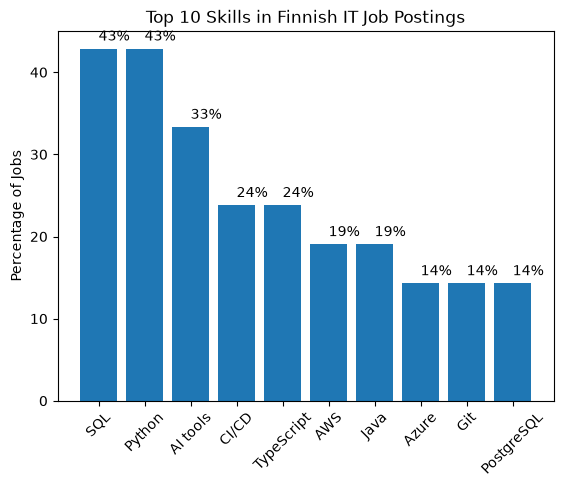

In [102]:
plt.bar(top10_skills["skill"],top10_skills["job_percentage"])

plt.title("Top 10 Skills in Finnish IT Job Postings")
plt.ylabel("Percentage of Jobs")
plt.xticks(rotation = 45)

for i, value in enumerate(top10_skills["job_percentage"]):
    plt.text(i, value + 1, f"{value:.0f}%")

plt.show()

### Key Finding

SQL and Python were the most frequenlty mentioned skills in the sample, each appearing in 9 of the 21 collected job posting (42.86%)

AI tools were the third most frequently mentioned skill, appearing in 7 posting (33.33%), followed by CI/CD and TypeScript at 23.81% each.

These finding describe the collected sample and should not be interpreted as representative of the entire Finish IT job market.

## 4. Skill Demand by Job Category

### Question

Which skills are most frequently mentioned within each job category?

### Method

Skills are grouped job category and counted bassed on the number of job posting mentioning each skill. Percentages are calculated using the number of job posting within each category


In [103]:
skill_category = (
    skills_long
    .groupby(["job_category","skill"])
    .size()
    .reset_index(name="job_count")
)

In [ ]:
category_job_counts = df["job_category"].value_counts()
skill_category["category_job_count"] = (
    skill_category["job_category"].map(category_job_counts)
)

In [73]:
skill_category["job_percentage"] = (
    round(skill_category["job_count"]
    /skill_category["category_job_count"]
    *100,2)
)

In [74]:
skill_category.head(10)

,job_category,skills_list,job_count,category_job_count,job_percentage
0,AIE,AI/ML,1,3,33.33
1,AIE,AIOps,1,3,33.33
2,AIE,API,1,3,33.33
3,AIE,APIs,1,3,33.33
4,AIE,AWS,1,3,33.33
5,AIE,Azure,1,3,33.33
6,AIE,CI/CD,1,3,33.33
7,AIE,CSS,1,3,33.33
8,AIE,Gen AI,2,3,66.67
9,AIE,HTML,1,3,33.33


### 4.2 Top Skills by Job Category

The top five skills for each job category are selected based on the percentage of posting within that category mentioning each skill.

In [75]:
top5_skills = (
    skill_category
    .sort_values(
        ["job_category","job_percentage"],
        ascending=[True,False]
    )
    .groupby("job_category")
    .head(5)
)

In [76]:
top5_skills

,job_category,skills_list,job_count,category_job_count,job_percentage
8,AIE,Gen AI,2,3,66.67
16,AIE,Python,2,3,66.67
0,AIE,AI/ML,1,3,33.33
1,AIE,AIOps,1,3,33.33
2,AIE,API,1,3,33.33
27,DTA,Power BI,3,4,75.00
19,DTA,AI tools,2,4,50.00
26,DTA,Microsoft Fabric,2,4,50.00
28,DTA,SQL,2,4,50.00
20,DTA,API/AI,1,4,25.00


### 4.3 Top 5 Skills by Job Category

The charts below compare the most frequently mentioned skills within each job category. Percentages represent the share of posting in that category mentioning each skill.

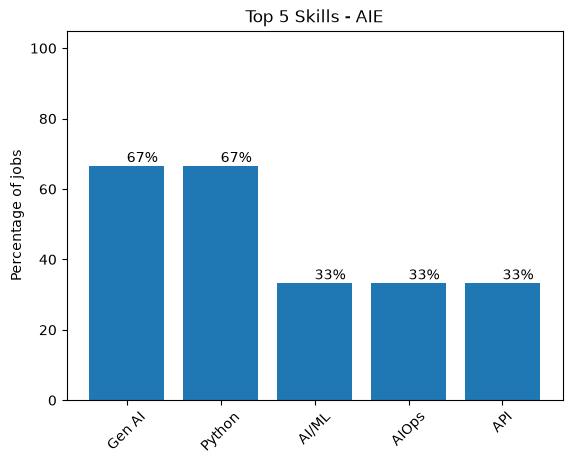

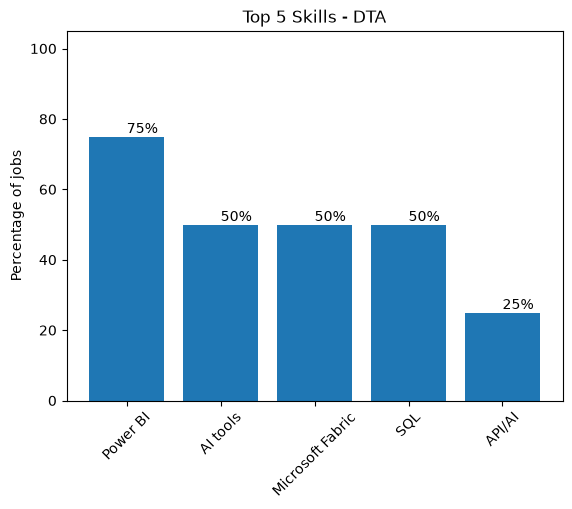

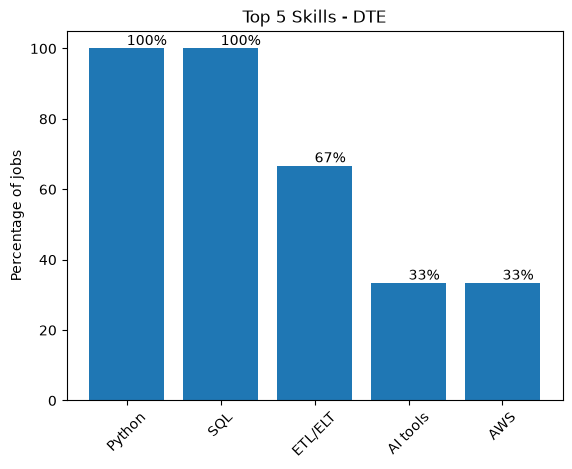

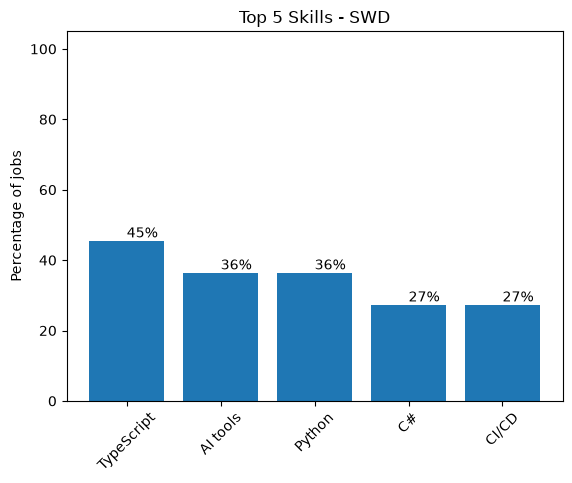

In [ ]:
for category in top5_skills["job_category"].unique():
    category_data = top5_skills[
        top5_skills["job_category"] == category
    ]
    plt.bar(
        category_data["skill"],
        category_data["job_percentage"]
    )
    plt.title(f"Top 5 Skills - {category}")
    plt.ylabel("Percentage of jobs")
    plt.xticks(rotation=45)
    plt.ylim(0,105)
    for i, value in enumerate(category_data["job_percentage"]):
        plt.text(i, value+1, f"{value:.0f}%")

    plt.show()


## 5. Cross-Category Skill

### Question

Which skill are shared across multiple job categories?

### Method

For each skill, the number of distinct job categories mentioning that skill is counted. This identifies skills that appear across different areas of the IT job market


In [ ]:
skill_category_overlap = (
    skills_long
    .groupby("skill")["job_category"]
    .nunique()
    .sort_values(ascending=False)
)

In [79]:
skill_category_overlap.head(10)

skills_list
SQL           4
CI/CD         3
AWS           3
AI tools      3
Python        3
Azure         3
PostgreSQL    2
React         2
Java          2
API           2
Name: job_category, dtype: int64

### Shared Skills Across Job Categories

The following skill appear across multiple job categories in the collected sample. The category count represent the number of distinct job categories in which each skill was mentioned.

In [106]:
shared_skills = (
    skill_category_overlap
    .reset_index(name="category_count")
)

In [105]:
shared_skills.head(10)

,skills_list,category_count
0,SQL,4
1,CI/CD,3
2,AWS,3
3,AI tools,3
4,Python,3
5,Azure,3
6,PostgreSQL,2
7,React,2
8,Java,2
9,API,2


### Key Finding

SQL was the only skill mentioned across all four categories in the collected sample.

Python, AI tools , CI/CD, AWS and Azure appeared across three of the four categories, indicating these skills were not limited to a single type of IT role. 

This overlap suggests that some technical skills shared across different areas of the IT job market, while other skills are more category-specific.

## 6. Limitations

This analysis is based on a small sample of 21 Finnish IT job postings collected for this project. The results should therefore be interpreted as exploratory rather than representative of the entire Finnish ITjob market.

Skill names were preserved largely as they appred in the original job posting. Some entries contain grouped alternatives, such as "Azure/AWS" or "SQL, NoSQL", which were not automatically split because doing so could change the meaning of the original requirement.

The number of posting also differ between job categories, which affects the reliability of percentage-based comparison.

## 7. Conclusion

The analysis shows that SQL and Python were the most frequently mentioned skills in the collected job postings, while skill demand varied substancially across job categories. 

Category-level analysis highlighted different patterns_ Power BI was prominent in Data Analyst postings, Python and SQL were common in Data Engineering, and Gen AI an Python appeared frequently in the AI Engineering sample.

At the same time, several skills, particular SQL, Python, AI tools, CI/CD, AWS, and Azure, appeared across multiple job categories.

Overall, the findings illistrated both the specialization and overlap of technical skills across the sampled Finnish IT job market.